In [22]:
#Importar las librerias necesarias
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

In [23]:
#Cargar predicciones desde la base de datos
conn = sqlite3.connect('C:/Users/Asus/OneDrive/Desktop/Workshop-003/database/predictions.db')
df_pred = pd.read_sql('SELECT * FROM predictions', conn)
df_pred.head(3)

,record_id,GDP,Social_Support,Life_Expectancy,Freedom,actual_score,predicted_score
0,0,1.426660,1.183260,0.867330,0.566240,7.501,6.617036
1,1,0.255580,0.758620,0.331080,0.391300,5.057,4.133409
2,2,0.586683,0.735132,0.533241,0.478357,4.608,4.892824


In [24]:
#Verificar el tamaño del DataFrame
df_pred.shape

(235, 7)

In [25]:
#Separar valores reales y predichos
y_test = df_pred['actual_score']
y_pred = df_pred['predicted_score']

In [26]:
#Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  0.4314
R2:   0.7619


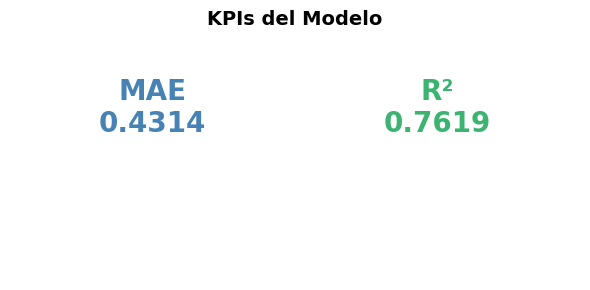

In [28]:
#KPIs visuales
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
ax.text(0.25, 0.6, f'MAE\n{mae:.4f}', fontsize=20, fontweight='bold',
        ha='center', color='steelblue')
ax.text(0.75, 0.6, f'R²\n{r2:.4f}', fontsize=20, fontweight='bold',
        ha='center', color='mediumseagreen')
ax.set_title('KPIs del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

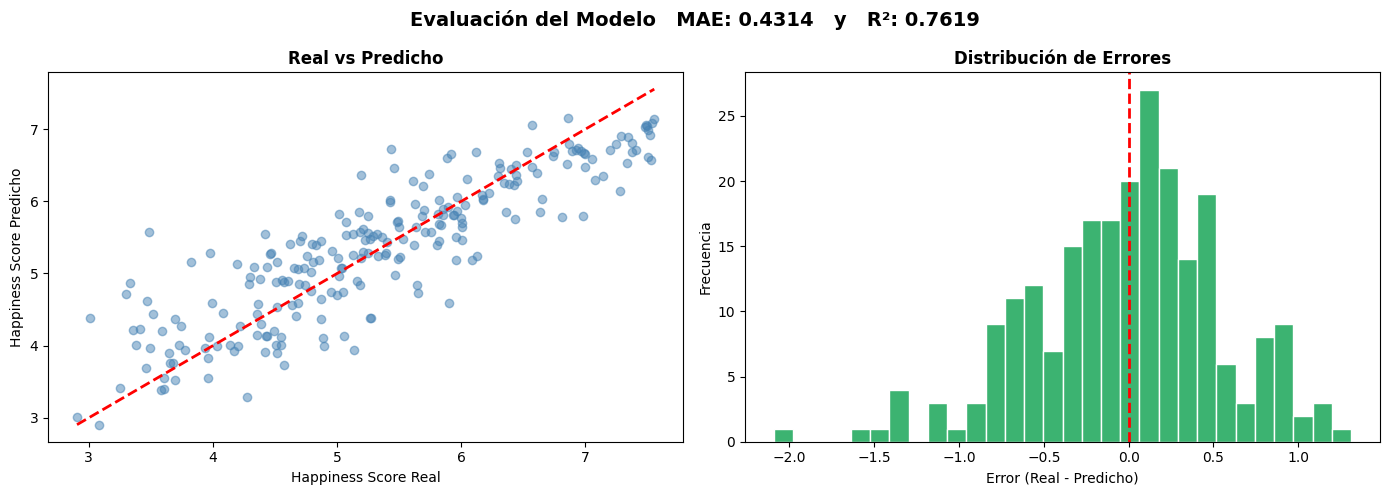

In [27]:
#Dashboard de métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#1.Real vs predicción
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             color='red', linewidth=2, linestyle='--')
axes[0].set_title('Real vs Predicho', fontweight='bold')
axes[0].set_xlabel('Happiness Score Real')
axes[0].set_ylabel('Happiness Score Predicho')

#2.Distribución de errores
errores = y_test - y_pred
axes[1].hist(errores, bins=30, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_title('Distribución de Errores', fontweight='bold')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Evaluación del Modelo   MAE: {mae:.4f}   y   R²: {r2:.4f}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/Asus/OneDrive/Desktop/Workshop-003/notebooks/model_evaluation.png', dpi=300)
plt.show()
#KPIs visuales
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis('off')
ax.text(0.25, 0.6, f'MAE\n{mae:.4f}', fontsize=20, fontweight='bold',
        ha='center', color='steelblue')
ax.text(0.75, 0.6, f'R²\n{r2:.4f}', fontsize=20, fontweight='bold',
        ha='center', color='mediumseagreen')
ax.set_title('KPIs del Modelo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Conclusiones para las métricas**

#### El modelo de Regresión Lineal se evaluó con R2 y MAE. Con un R² de 0.76, el modelo explica bien la relación entre las variables GDP, Social Support, Life Expectancy y Freedom con el Happiness Score. El MAE de 0.43 muestra que las predicciones son bastante cercanas a los valores reales. Se puede ver que en la gráfica de real vs predicción los puntos siguen bien la línea de referencia y los errores se distribuyen alrededor de cero, lo que indica que el modelo no sobreestima ni subestima de forma consistente. En conclusión, el modelo tiene un buen desempeño para ser lineal y con pocas variables.